In [1]:
import cv2
import numpy as np
import os
import glob
from tqdm import tqdm
from PIL import Image

# 1. Re-define Necessary Paths (ดึงจาก EDA ที่เราทำไว้)
BASE_DIR = r"D:\MesidorDataset"
COLLECTION_DIR = os.path.join(BASE_DIR, "MAPLES_Matched")
COLLECTION_IMAGES = os.path.join(COLLECTION_DIR, "images")
COLLECTION_MASKS = os.path.join(COLLECTION_DIR, "masks")

# Create Output Directories
PROCESSED_DIR = os.path.join(BASE_DIR, "Processed_Dataset")
X_DIR = os.path.join(PROCESSED_DIR, "images")
Y_DIR = os.path.join(PROCESSED_DIR, "masks_multichannel")

for d in [X_DIR, Y_DIR]:
    os.makedirs(d, exist_ok=True)

# 2. Configuration
TARGET_SIZE = (512, 512)
TARGET_CLASSES = ['OpticDisc', 'Macula', 'Exudates', 'Hemorrhages', 'Drusens']

def preprocess_image_and_masks(img_id):
    # --- Process Image ---
    img_search = glob.glob(os.path.join(COLLECTION_IMAGES, f"{img_id}.*"))
    if not img_search: return None, None
    
    img_path = img_search[0]
    img = cv2.imread(img_path)
    if img is None: return None, None
    
    h, w = img.shape[:2]
    
    # Square Padding (เพื่อรักษา Aspect Ratio ไม่ให้ดวงตาเบี้ยว)
    max_side = max(h, w)
    pad_h = (max_side - h) // 2
    pad_w = (max_side - w) // 2
    img_padded = cv2.copyMakeBorder(img, pad_h, (max_side - h) - pad_h, 
                                    pad_w, (max_side - w) - pad_w, 
                                    cv2.BORDER_CONSTANT, value=[0,0,0])
    
    # Resize & CLAHE (เพิ่ม Contrast ให้รอยโรคชัดขึ้น)
    img_resized = cv2.resize(img_padded, TARGET_SIZE, interpolation=cv2.INTER_CUBIC)
    lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    img_enhanced = cv2.cvtColor(cv2.merge((l,a,b)), cv2.COLOR_LAB2RGB)
    
    # --- Process Multi-channel Mask (6 Layers) ---
    multichannel_mask = np.zeros((TARGET_SIZE[1], TARGET_SIZE[0], len(TARGET_CLASSES)), dtype=np.uint8)
    
    for i, cls in enumerate(TARGET_CLASSES):
        m_path = os.path.join(COLLECTION_MASKS, cls, f"{img_id}.png")
        if os.path.exists(m_path):
            m = cv2.imread(m_path, cv2.IMREAD_GRAYSCALE)
            # Pad และ Resize Mask ให้สัมพันธ์กับภาพหลัก
            m_padded = cv2.copyMakeBorder(m, pad_h, (max_side - h) - pad_h, 
                                          pad_w, (max_side - w) - pad_w, 
                                          cv2.BORDER_CONSTANT, value=0)
            m_resized = cv2.resize(m_padded, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)
            # Threshold เพื่อความชัวร์ (Binarization)
            multichannel_mask[:, :, i] = (m_resized > 0).astype(np.uint8)
            
    return img_enhanced, multichannel_mask

# 3. Execution Loop
all_ids = [os.path.splitext(f)[0] for f in os.listdir(COLLECTION_IMAGES) if not f.startswith('._')]

print(f"Starting Preprocessing for {len(all_ids)} images...")

for img_id in tqdm(all_ids, desc="Final Preprocessing"):
    try:
        processed_img, processed_mask = preprocess_image_and_masks(img_id)
        
        if processed_img is not None:
            # Save Image (PNG เพื่อไม่ให้เสียรายละเอียดจากการบีบอัด)
            cv2.imwrite(os.path.join(X_DIR, f"{img_id}.png"), cv2.cvtColor(processed_img, cv2.COLOR_RGB2BGR))
            # Save Mask เป็น Numpy Binary เพื่อความเร็วในการโหลดตอนเทรน
            np.save(os.path.join(Y_DIR, f"{img_id}.npy"), processed_mask)
    except Exception as e:
        print(f"Error processing {img_id}: {e}")

print(f"\n--- Done! ---")
print(f"Images in '{X_DIR}': {len(os.listdir(X_DIR))}")
print(f"Masks in '{Y_DIR}': {len(os.listdir(Y_DIR))}")

Starting Preprocessing for 198 images...


Final Preprocessing: 100%|██████████| 198/198 [00:16<00:00, 12.30it/s]


--- Done! ---
Images in 'D:\MesidorDataset\Processed_Dataset\images': 198
Masks in 'D:\MesidorDataset\Processed_Dataset\masks_multichannel': 198


Step 1.5: CLAHE & LAB Visual Audit (ตรวจสอบผลการปรับปรุงภาพ)
รันสคริปต์นี้เพื่อเปรียบเทียบภาพ "ก่อน" และ "หลัง" ทำ Preprocessing ครับ เราจะดึงภาพต้นฉบับมาเทียบกับภาพที่อยู่ในโฟลเดอร์ Processed_Dataset

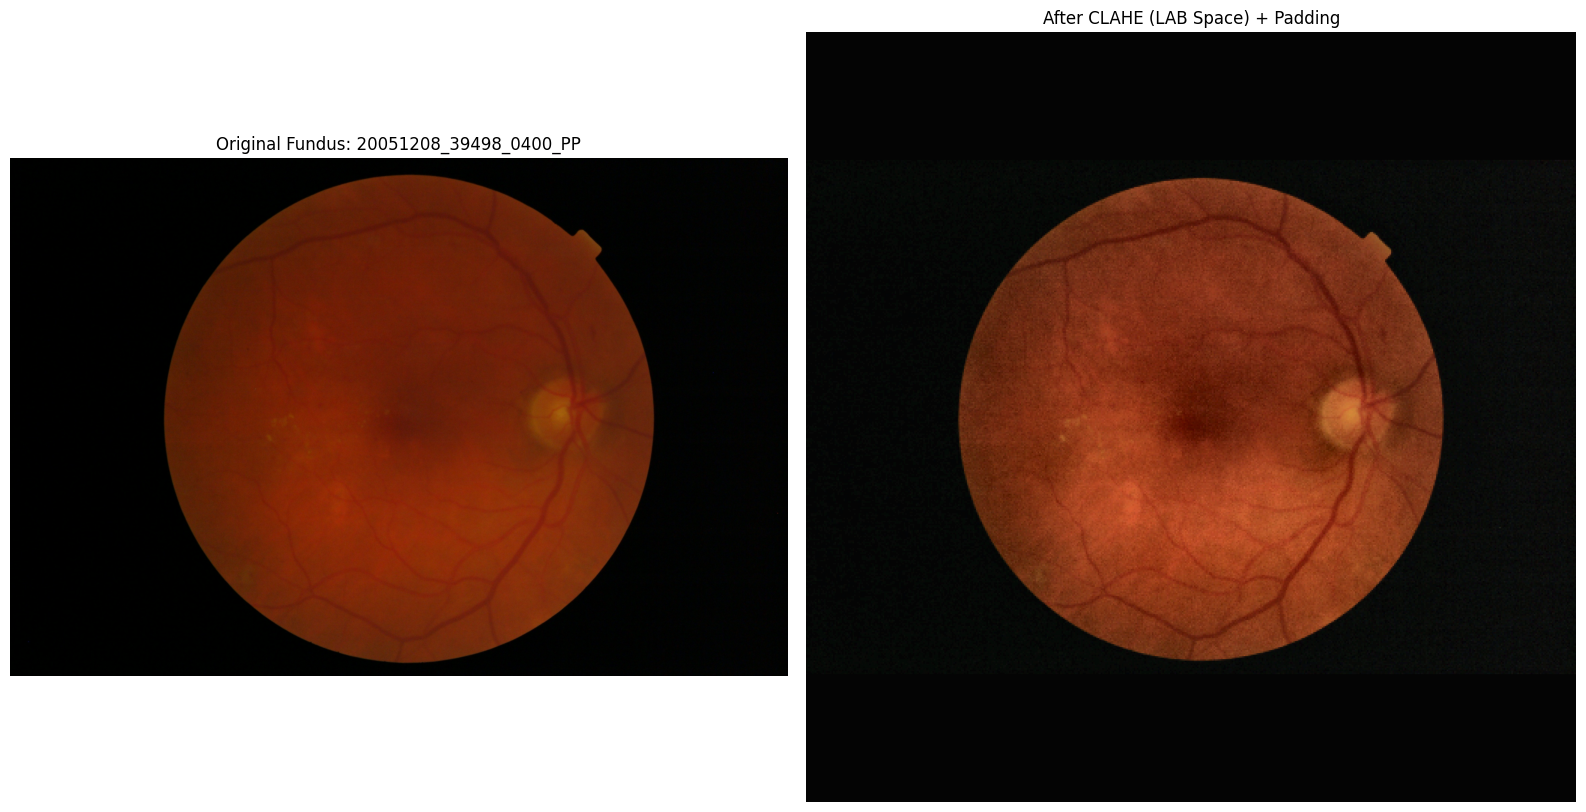

In [2]:
# ── ตรวจสอบผลลัพธ์ของ CLAHE ──
import matplotlib.pyplot as plt
import cv2
import os
import random

# เลือกสุ่มรูปมา 1 ใบ
sample_id = random.choice(all_ids)

# 1. ภาพต้นฉบับ (Original)
original_path = glob.glob(os.path.join(COLLECTION_IMAGES, f"{sample_id}.*"))[0]
img_orig = cv2.imread(original_path)
img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

# 2. ภาพที่ผ่านการ Preprocess (CLAHE + Resize + Pad)
processed_path = os.path.join(X_DIR, f"{sample_id}.png")
img_proc = cv2.imread(processed_path)
img_proc = cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB)

# แสดงผลเปรียบเทียบ
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(img_orig)
plt.title(f"Original Fundus: {sample_id}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_proc)
plt.title("After CLAHE (LAB Space) + Padding")
plt.axis('off')

plt.tight_layout()
plt.show()

Step 2: Multi-label Stratified Splitting
เราต้องมั่นใจว่าในเซต Train, Validation, และ Test จะมีสัดส่วนของรอยโรคทั้ง 5 ชนิดกระจายตัวอยู่อย่างเท่าเทียมกัน (สมมติถ้าเราสุ่มแล้วภาพที่มี Drusens ไปกองอยู่ใน Test หมด โมเดลจะไม่มีโอกาสได้เรียนรู้การตรวจจับ Drusens เลยตอน Train)

เราจะใช้เทคนิค Multilabel Stratification เพื่อแบ่งข้อมูลเป็น 70% / 15% / 15% ครับ

In [19]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

print("1. เริ่มทำการแบ่ง Train/Val/Test แบบข้ามกลุ่มที่มี 1 รูป...")

# สร้างคีย์จัดกลุ่มด้วยบาร์โค้ด 0/1 เหมือนเดิม
df_occ['stratify_key'] = df_occ[TARGET_CLASSES].astype(str).agg(''.join, axis=1)

# =======================================================
# ── Trick: ดึงภาพที่มี 1 รูปแยกออกมาก่อน จะได้ไม่พัง ──
# =======================================================
key_counts = df_occ['stratify_key'].value_counts()
rare_keys = key_counts[key_counts < 2].index

# แยกภาพกลุ่มหายาก (1 รูป) กับ กลุ่มปกติ (2 รูปขึ้นไป)
rare_df = df_occ[df_occ['stratify_key'].isin(rare_keys)].copy()
normal_df = df_occ[~df_occ['stratify_key'].isin(rare_keys)].copy()

print(f"-> ดึงภาพคอมโบหายาก (มีแค่รูปเดียว) ออกไป {len(rare_df)} รูป (รอส่งตรงเข้า Train Set)")

# =======================================================
# ── เริ่มแบ่งข้อมูลเฉพาะกลุ่มภาพปกติ ──
# =======================================================
# แบ่งรอบแรก (Train 70% / Temp 30%)
train_normal, temp_df = train_test_split(
    normal_df, 
    test_size=0.30, 
    random_state=42, 
    stratify=normal_df['stratify_key']
)

# ก่อนแบ่งรอบสอง เช็คว่ามีกลุ่มไหนหลุดมาเหลือ 1 รูปในกอง Temp ไหม
temp_counts = temp_df['stratify_key'].value_counts()
rare_in_temp = temp_counts[temp_counts < 2].index

rare_temp_df = temp_df[temp_df['stratify_key'].isin(rare_in_temp)].copy()
normal_temp_df = temp_df[~temp_df['stratify_key'].isin(rare_in_temp)].copy()

print(f"-> ดึงภาพเศษที่เหลือ 1 รูปในกอง Temp ออกไปอีก {len(rare_temp_df)} รูป")

# แบ่งรอบสอง (Val 15% / Test 15%)
val_df, test_df = train_test_split(
    normal_temp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=normal_temp_df['stratify_key']
)

# =======================================================
# ── ประกอบร่าง! นำภาพหายากที่ดึงไว้ ใส่กลับเข้า Train Set ──
# =======================================================
train_df = pd.concat([train_normal, rare_df, rare_temp_df], ignore_index=True)

print(f"\n--- Data Split Summary (Ultimate Fix) ---")
print(f"Train set: {len(train_df)} images ({len(train_df)/len(df_occ):.1%})")
print(f"Val set:   {len(val_df)} images ({len(val_df)/len(df_occ):.1%})")
print(f"Test set:  {len(test_df)} images ({len(test_df)/len(df_occ):.1%})")

# บันทึกผลลง CSV 
train_df.to_csv(os.path.join(PROCESSED_DIR, "train_split.csv"), index=False)
val_df.to_csv(os.path.join(PROCESSED_DIR, "val_split.csv"), index=False)
test_df.to_csv(os.path.join(PROCESSED_DIR, "test_split.csv"), index=False)

# ตรวจสอบการกระจายตัวของโรค
summary = pd.DataFrame({
    'Train': train_df[TARGET_CLASSES].sum(),
    'Val': val_df[TARGET_CLASSES].sum(),
    'Test': test_df[TARGET_CLASSES].sum()
})
display(summary)

print("\n✅ แก้ไขปัญหา Stratify สำเร็จ! โค้ดผ่านฉลุยพร้อมนำไฟล์ไปเทรนแล้วครับ")

1. เริ่มทำการแบ่ง Train/Val/Test แบบข้ามกลุ่มที่มี 1 รูป...
-> ดึงภาพคอมโบหายาก (มีแค่รูปเดียว) ออกไป 1 รูป (รอส่งตรงเข้า Train Set)
-> ดึงภาพเศษที่เหลือ 1 รูปในกอง Temp ออกไปอีก 0 รูป

--- Data Split Summary (Ultimate Fix) ---
Train set: 138 images (69.7%)
Val set:   30 images (15.2%)
Test set:  30 images (15.2%)


,Train,Val,Test
OpticDisc,138,30,30
Macula,137,30,30
Exudates,73,16,15
Hemorrhages,85,19,18
Drusens,62,14,14



✅ แก้ไขปัญหา Stratify สำเร็จ! โค้ดผ่านฉลุยพร้อมนำไฟล์ไปเทรนแล้วครับ
